# Using DECam Images to Subtract DP1 Images

**Description:** This notebook demonstrates how to use SLIDE to perform image subtraction on LSST data using DECam templates

**author:** Yize Dong

**email:** yize.dong@cfa.harvard.edu



## load packages

In [1]:
import numpy as np
from astropy.time import Time
import matplotlib.pyplot as plt
from astropy.io import fits
from slide_lsst.subtraction import lsst_decam_data_load, lsst_decam_data_load_coadd, perform_image_subtraction, load_user_decam
from slide_lsst.lsst_utils import query_lsst_visits, astropy_world_to_pixel, forced_phot, safe_cutout2d
from lsst.daf.butler import Butler
from astropy.visualization import PercentileInterval, ImageNormalize

Please note the archive will not be accessible on 29 July from 11 to 13 CEST, for maintenance purposes. Apologies for the inconveniences.


In [2]:
butler = Butler('dp2', collections=["dp2"])

## query images

Find images that contain the source we are interested. We will only reduce one image as an example

In [3]:
ra, dec = 347.253326,  -7.518835 
band = 'g'
data_query = query_lsst_visits(butler=butler, ra=ra, dec=dec, band=band, image_type='coadd')

In [4]:
data_query

[DatasetRef(DatasetType('deep_coadd', {band, skymap, tract, patch}, CellCoadd), {band: 'g', skymap: 'lsst_cells_v2', tract: 8250, patch: 80}, run='LSSTCam/runs/DRP/DP2/v30_0_8/DM-55060/deep_coadd_rewrite/20260618T031503Z', id=019ed8bf-2d21-707d-b907-e6c6381e968f),
 DatasetRef(DatasetType('deep_coadd', {band, skymap, tract, patch}, CellCoadd), {band: 'g', skymap: 'lsst_cells_v2', tract: 8250, patch: 90}, run='LSSTCam/runs/DRP/DP2/v30_0_8/DM-55060/deep_coadd_rewrite/20260618T031503Z', id=019ed8bf-dd29-73e6-a684-721a22502ae5),
 DatasetRef(DatasetType('deep_coadd', {band, skymap, tract, patch}, CellCoadd), {band: 'g', skymap: 'lsst_cells_v2', tract: 8251, patch: 89}, run='LSSTCam/runs/DRP/DP2/v30_0_8/DM-55060/deep_coadd_rewrite/20260618T031503Z', id=019ed8bf-0f97-79cd-a55c-0442f2c36386),
 DatasetRef(DatasetType('deep_coadd', {band, skymap, tract, patch}, CellCoadd), {band: 'g', skymap: 'lsst_cells_v2', tract: 8251, patch: 99}, run='LSSTCam/runs/DRP/DP2/v30_0_8/DM-55060/deep_coadd_rewrite/2

In [5]:
visit_image = butler.get(data_query[0])

Check the mjds of the visit images used to create the coadd

In [6]:
inputs = visit_image.provenance.inputs
visit_ids = [int(v) for v in np.unique(inputs["visit"])]
inst = str(inputs["instrument"][0])

mjds = np.sort([
    0.5 * (rec.timespan.begin.mjd + rec.timespan.end.mjd)
    for rec in butler.query_dimension_records(
        "visit", where="instrument = :inst AND visit IN (visits)",
        bind={"inst": inst, "visits": visit_ids})
])

for label, mjd in [("median", np.median(mjds)),
                   ("earliest", mjds.min()),
                   ("latest", mjds.max())]:
    print(f"{label:8s} {mjd:.5f}  {Time(mjd, format='mjd', scale='tai').isot}")

median   60891.20916  2025-08-04T05:01:11.740
earliest 60875.24347  2025-07-19T05:50:36.088
latest   61001.09079  2025-11-22T02:10:44.356


## Prepare for the difference imaging step

This step will download the templates from DES-DR2, generate PSFs for the images, and align the template image with the science image.

- To perform subtraction on a cutout (as in this example), set **`cutout=True`** and specify the cutout size in pixels using **`cutout_size=1000`**.
- To run subtraction on the full CCD image, set **`cutout=False`**.
- To save the science and template images, set **`save_intermediate=True`**. The images will be saved to the specified **`workdir`**.
- To use templates from DeCaLS instead of DES, set **`download_DES_temp=False`** and **`download_DECaLS_temp=True`**.
- Set **`reference_center = 'target'`** if you want to query the template based on the target coordinates; or **`reference_center = 'center'`** if you want to query the template based on the center.
- Use **`reprojection_parallel = 6`** to control the number of workers for template image resampling. 
- Set **`refine_wcs_sci=True`** to refine the WCS of the DP1 images. This is probably not necessary since the DP1 WCS is very good.
- Set **`make_sci_psf=True`** if you want to regenerate the science PSF (this may improve the subtraction when the image quality is bad).

INFO: Query finished. [astroquery.utils.tap.core]


/home/ydong/git/SLIDE/slide_lsst/subtraction.py:148: RuntimeWarning: All-NaN slice encountered
  refdata_reproj = np.nanmedian(refdatas_reprojected, axis=0)


EPSFBuilder (10 maxiters):   0%|          | 0/10 [00:00<?, ?it/s]

EPSFBuilder converged after 4 iterations (of 10 maximum iterations)


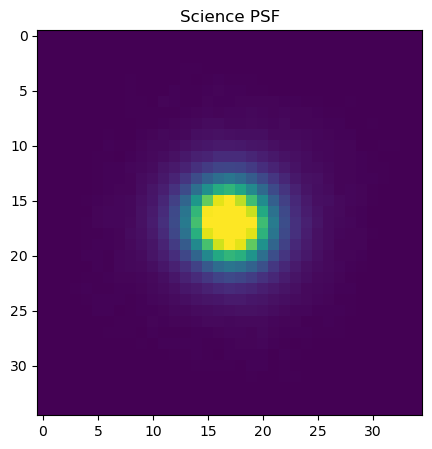

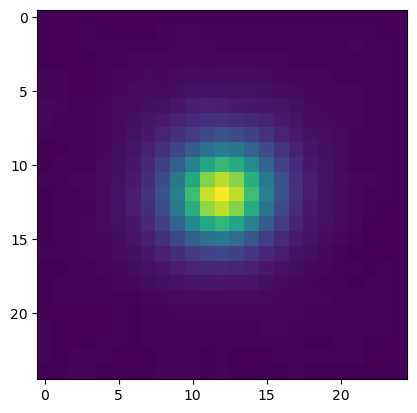

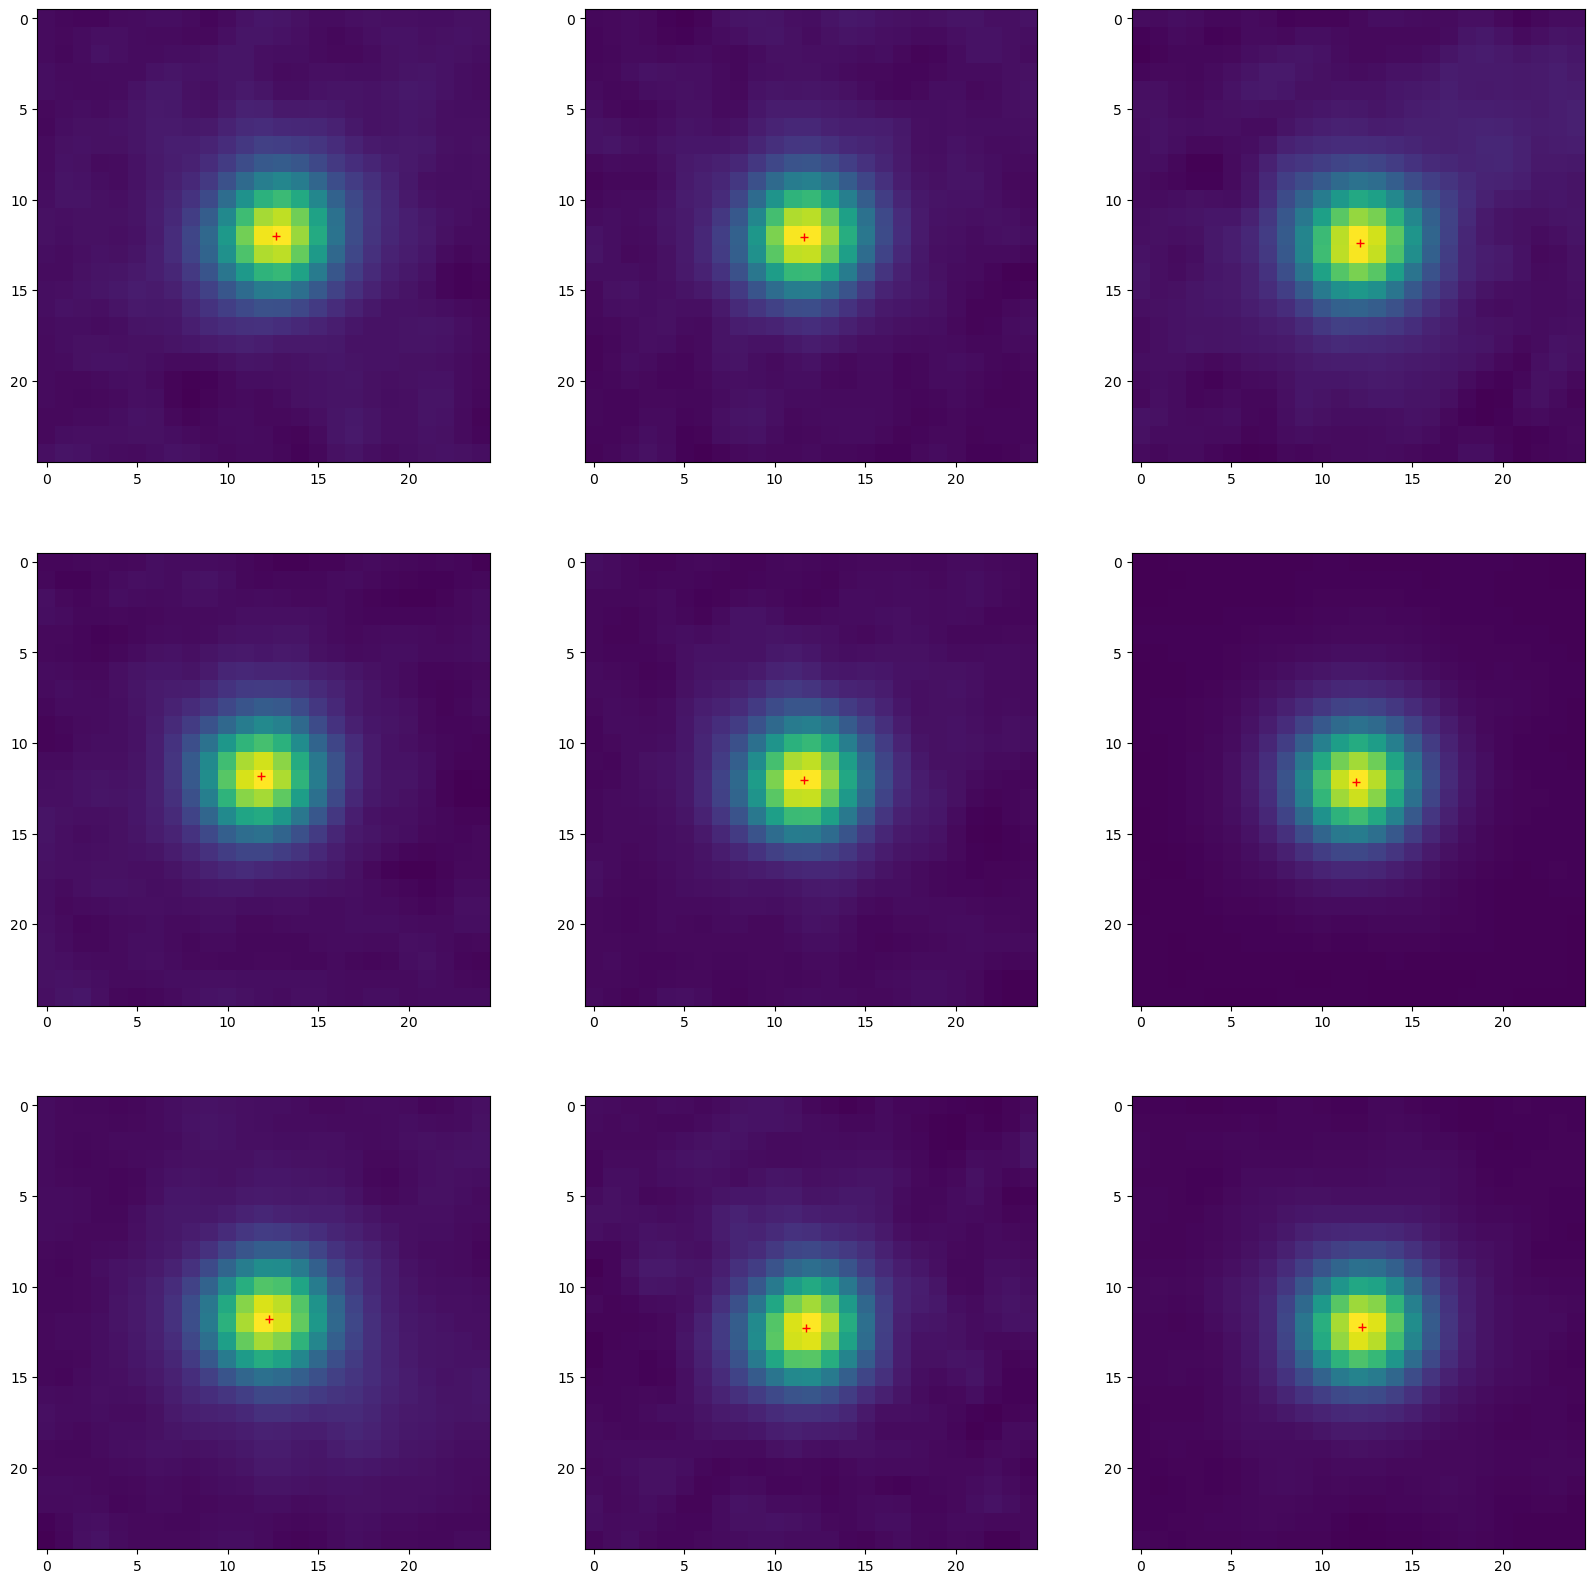

In [7]:
scidata, refdata, sci_psf, ref_psf = lsst_decam_data_load_coadd(visit_image, ra = ra, dec = dec, download_DES_temp=True, download_DECaLS_DR9_temp=False,
                                                          show=True, reference_center = 'target',
                                                          refine_wcs_sci=True, make_sci_psf=False, get_median_sci_psf=True,
                                                          cutout=True, cutout_size=1500, reference_catalog='gaia', workdir='./',
                                                          reprojection_parallel=6,
                                                          save_intermediate=False)

## Image subtraction

This step performs image subtraction and returns the aligned template, the final difference image, and the PSF to be used for the photometry stage.

Note: This process can take some time depending on the image size.

- Set **`fast_mode=True`** to use a modified version of loading images and use the flux zero points directly from LSST and DES/DECaLS. This is the recommended mode. The image subtraction will be fast and reliable.
- To save the difference images, set **`save_diff=True`**. The images will be saved to the specified **`workdir`**.
- The server on RSP has a memory limit of 16 GB. To protect the server from crashing, you can set **`protect_mem=True`**. This is probably not necessary if you turn the `fast_mode` on.


In [8]:
normalized_difference, diff_psf = perform_image_subtraction(scidata, refdata, sci_psf, ref_psf, fast_mode=True,
                          save_diff=False, workdir='./', show=True, sigma_cut=5, max_iterations=3, protect_mem=False)

## Display the results

Text(0.5, 1.0, 'difference')

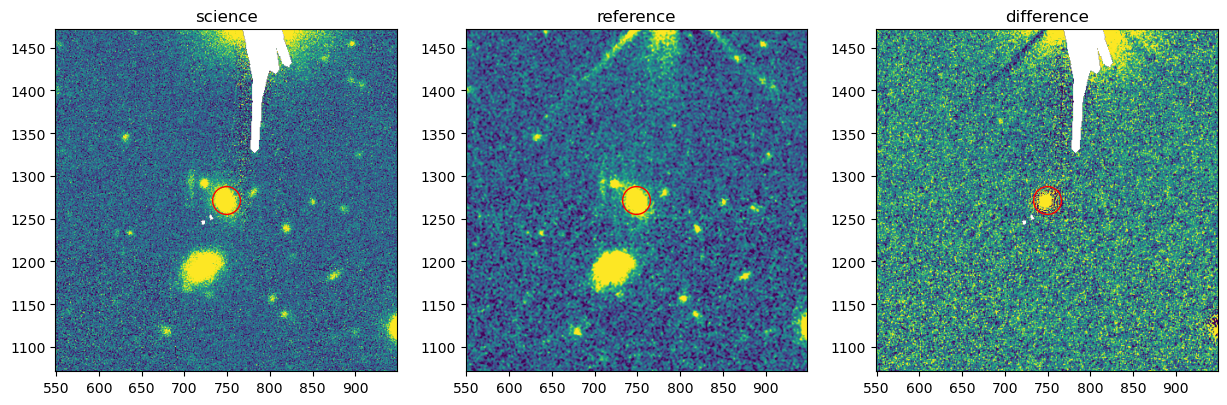

In [9]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 15))
norm = ImageNormalize(scidata.data, PercentileInterval(98))
ax1.imshow(scidata, norm=norm)
_x, _y = astropy_world_to_pixel(ra, dec, scidata.wcs)
ax1.plot(_x, _y, marker='o', mec='r', mfc='none', ls='none', markersize=20)
ax1.set_xlim(_x-200, _x+200)
ax1.set_ylim(_y-200, _y+200)
ax1.set_title('science')

norm = ImageNormalize(refdata.data, PercentileInterval(98))
ax2.imshow(refdata, norm=norm)
ax2.plot(_x, _y, marker='o', mec='r', mfc='none', ls='none', markersize=20)
ax2.set_xlim(_x-200, _x+200)
ax2.set_ylim(_y-200, _y+200)
ax2.set_title('reference')

norm = ImageNormalize(normalized_difference.data, PercentileInterval(98))
ax3.imshow(normalized_difference, norm=norm)
ax3.plot(_x, _y, marker='o', mec='r', mfc='none', ls='none', markersize=20)
ax3.set_xlim(_x-200, _x+200)
ax3.set_ylim(_y-200, _y+200)
ax3.set_title('difference')

## Do photometry on the difference image at the provided position

In [10]:
flux_njy, flux_err, mag, mag_err, upper_limit = forced_phot(ra, dec, normalized_difference, scidata.wcs, diff_psf)
print(f"Flux: {flux_njy:.2f} ± {flux_err:.2f} nJy\nMag: {mag:.2f} ± {mag_err:.2f}\nUpper limit: {upper_limit:.2f}")

Flux: 91848.13 ± 1494.63 nJy
Mag: 18.99 ± 0.02
Upper limit: 21.72
